# A-D Wandler

In [106]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt

font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 11}

matplotlib.rc('font', **font)

## Berechnung der Umsetzerkennlinien

ADC Parameter

In [107]:
u_fsr = 5
n_bits = 4
n_levels = 2 ** n_bits
codes = np.arange(-n_levels/2, n_levels/2)

### Ideale AD Umsetzerkennlinie

In [108]:
# Stufenmittelpunkte
u_mid = np.arange(-u_fsr/2, +u_fsr/2, u_fsr / n_levels)
# Stufenbreite
u_width = np.ones(n_levels) * u_fsr / n_levels
# Umschaltspunkte
u_edge = u_mid + u_width / 2

Ausgabe der Idealen Kennlinie

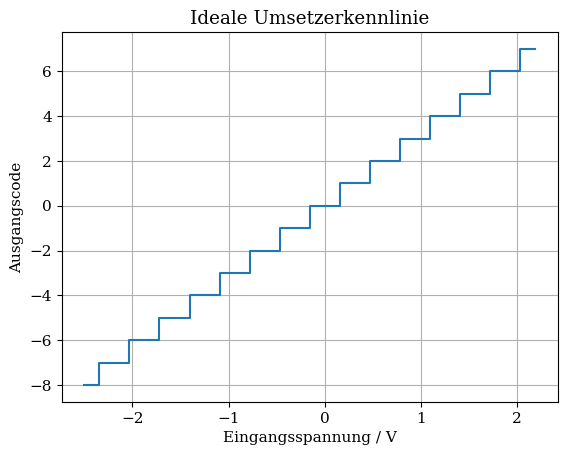

In [109]:
plt.step(u_mid, codes, where='mid')
plt.title('Ideale Umsetzerkennlinie')
plt.xlabel('Eingangsspannung / V')
plt.ylabel('Ausgangscode')
plt.grid(True)
plt.show()

### Reale Messwerte

Schwellen des realen AD Umsetzers messen

In [ ]:
# starte bei code -8
u_edge_flash = np.array([
    -2.233,
    -2.085,
    -1.748,
    -1.452,
    -1.102,
    -0.895,
    -0.541,
    -0.404,
    -0.039,
    0.045,
    0.787,
    1.118,
    1.428,
    1.612,
    1.939
])

In [ ]:
u_edge_sar = np.array([
    -2.578, # -8 -> -7
    -2.179, # -7 -> -6
    -1.78,  # -6 -> -5
    -1.61,  # -5 -> -4
    -1.234, # -4 -> -3
    -0.913, # -3 -> -2
    -0.487, # -2 -> -1
    -0.135, # -1 -> 0
    0.498, # 0 -> 1
    0.876, # 1 -> 2
    1.217, # 2 -> 3
    1.339, # 3 -> 4
    1.785, # 4 -> 5
    2.113, # 5 -> 6
    2.533 # 6 -> 7
])

### Auswertung

Korrektur der Werte

In [111]:
u_edge_diff = abs(u_edge_real - u_edge[:-1])

pos_end = u_edge_diff[-2]
neg_end = u_edge_diff[0]
null_pt = u_edge_diff[int(n_levels/2)]

n_vals = n_levels-2
u_edge_korr = np.array([
	u_edge_real[i] - (neg_end*i + pos_end*(n_vals-i))/n_vals
	for i in range(n_vals+1)
])

In [112]:
u_width_real = np.array([
	u_edge_korr[i+1] - u_edge_korr[i]
	for i in range(n_levels-2)
])
u_mid_real = u_edge_korr[:-1] + u_width_real / 2

u_width_diff = np.abs(u_width_real - u_width[1:-1])
u_mid_diff = np.abs(u_mid_real - u_mid[1:-1])

dnl = np.max(np.abs(u_width_diff))
inl = np.max(np.abs(u_mid_diff))

In [113]:
errors = {
    'pos_end': pos_end,
    'neg_end': neg_end,
    'null_pt': null_pt,
    'dnl': dnl,
    'inl': inl
}
pd.DataFrame(data=errors, index=[''])

,pos_end,neg_end,null_pt,dnl,inl
,0.10675,0.11075,0.19525,0.429214,0.418679


In [114]:
df_codes = pd.DataFrame({ 'Code': codes })
df = pd.merge(pd.DataFrame({
	'Code': codes[:-1],
	'U_edge_real': u_edge_real,
	'U_edge_ideal': u_edge[:-1],
	'U_edge_diff': u_edge_diff
}), pd.DataFrame({
	'Code': codes[1:-1],
	'U_width_real': u_width_real,
	'U_width_ideal': u_width[1:-1],
	'U_width_diff': u_width_diff,
	'U_mittel_real': u_mid_real,
	'U_mittel_ideal': u_mid[1:-1],
	'U_mittel_diff': u_mid_diff
}), how='left', on='Code')

# merge dataframes on code
pd.merge(df_codes, df, how='left', on='Code')

,Code,U_edge_real,U_edge_ideal,U_edge_diff,U_width_real,U_width_ideal,U_width_diff,U_mittel_real,U_mittel_ideal,U_mittel_diff
0,-8.0,-2.233,-2.34375,0.11075,NaN,NaN,NaN,NaN,NaN,NaN
1,-7.0,-2.085,-2.03125,0.05375,0.147714,0.3125,0.164786,-2.265893,-2.1875,0.078393
2,-6.0,-1.748,-1.71875,0.02925,0.336714,0.3125,0.024214,-2.023679,-1.8750,0.148679
3,-5.0,-1.452,-1.40625,0.04575,0.295714,0.3125,0.016786,-1.707464,-1.5625,0.144964
4,-4.0,-1.102,-1.09375,0.00825,0.349714,0.3125,0.037214,-1.384750,-1.2500,0.134750
5,-3.0,-0.895,-0.78125,0.11375,0.206714,0.3125,0.105786,-1.106536,-0.9375,0.169036
6,-2.0,-0.541,-0.46875,0.07225,0.353714,0.3125,0.041214,-0.826321,-0.6250,0.201321
7,-1.0,-0.404,-0.15625,0.24775,0.136714,0.3125,0.175786,-0.581107,-0.3125,0.268607
8,0.0,-0.039,0.15625,0.19525,0.364714,0.3125,0.052214,-0.330393,0.0000,0.330393
9,1.0,0.045,0.46875,0.42375,0.083714,0.3125,0.228786,-0.106179,0.3125,0.418679


Ausgabe der Realen Kennlinie über der Idealen

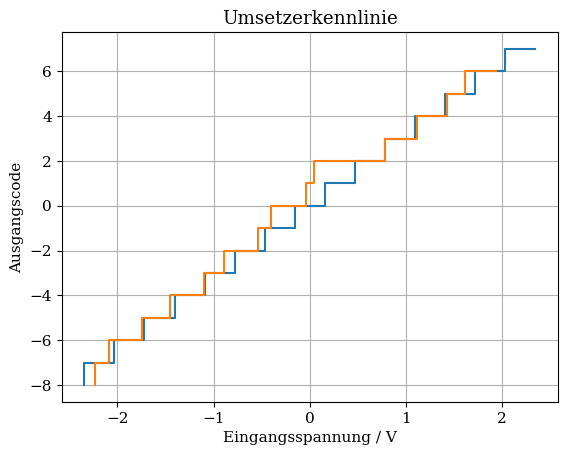

In [115]:
plt.step(u_edge, codes, where='pre')
plt.step(u_edge_real, codes[:-1], where='pre')
plt.title('Umsetzerkennlinie')
plt.xlabel('Eingangsspannung / V')
plt.ylabel('Ausgangscode')
plt.grid(True)
plt.show()